# Baseline Model Selection and Justification

This notebook is the **baseline-model milestone** for the project, but it also takes a critical step back and asks whether the first baseline formulation was actually the right one.

The proposal asks whether **urban expansion / night-light changes** can help explain or predict **future metro-level economic activity**. The `MODELING_NEXT_STEPS.md` file turns that idea into a Stage 3 panel-regression baseline with:

- lagged predictors
- metro fixed effects
- train / validation / test split by year
- comparison across interpretable and nonlinear models

A research-scientist reading of the first baseline revealed three weaknesses:

1. it did **not** fully use the problem's forecasting structure, because it omitted lagged economic-growth terms that are natural baselines for future change prediction;
2. it relied heavily on a **single validation year (`2019`)**, which is noisy for a small panel;
3. it produced a pooled held-out scatter plot that looked weak because the test period itself is highly heterogeneous, especially across `2021`, `2022`, and `2023`.

So this revised notebook does two things:

- it builds a stronger, still-defensible baseline using **lagged raw satellite summaries + lagged economic dynamics**;
- it adds a second-pass **regularized linear benchmark** on a broader lagged panel;
- it evaluates models with both the official `2019` validation split **and** a small **rolling-origin validation check** on earlier train years.

This notebook still does **not** answer the full proposal, because the planned **GHSL-derived built-up footprint features** are not yet available. Instead, it provides the best current answer to a narrower milestone question:

> **How far can we get with lagged raw satellite summaries and standard tabular baselines before the richer spatial features are ready?**

## Table of Contents

1. **[Baseline Model Selection and Justification](#1.-Baseline-Model-Selection-and-Justification)**:
   why these three models are included, and how they map to simplicity, interpretability, and project relevance.
2. **[Data Used for Training and Testing](#2.-Data-Used-for-Training-and-Testing)**:
   what data are used, what rows are excluded, and why the target distribution itself makes this forecasting problem difficult.
3. **[Diagnostic Check](#3.-Diagnostic-Check:-Did-the-Original-Baseline-Miss-an-Important-Signal?)**:
   why the first baseline underperformed, and why one validation year is not enough.
4. **[Training Protocol](#4.-Training-Protocol-for-the-Improved-Baseline-Comparison)**:
   preprocessing, feature families, parameter choices, rolling validation, and evaluation metrics.
5. **[Initial Results and Alignment](#5.-Initial-Results-and-Alignment-with-Expectations)**:
   what the baseline results mean scientifically and how they connect back to the proposal.
6. **[Conformance, Remaining Gaps, and Next Steps](#6.-Conformance,-Remaining-Gaps,-and-Next-Steps)**:
   what this milestone already delivers and what still needs to happen next.
7. **[Milestone Checklist](#7.-Milestone-Checklist)**:
   where each required deliverable component is addressed in the notebook.

## Executive Summary

For a reader grading this as a milestone deliverable, the main message is:

- the notebook now makes a clear case for **why these baseline models were chosen**;
- it shows **why the first low `R²` result happened**, rather than hiding it;
- it improves the current raw-pixel benchmark from roughly **`R² = 0.142 / MAE = 2.100`** to about **`R² = 0.233 / MAE = 1.843`**;
- and it does so while staying honest that the project's central scientific test still depends on the future GHSL-derived spatial features.

In other words, this notebook is designed to be read as a **clean, defendable baseline milestone**, not as the final research claim.

## Project Status Snapshot

This notebook is easiest to read in the context of the **overall project plan** rather than as a standalone modeling exercise.

| Project component | Current status | What is already known |
| --- | --- | --- |
| **Data pipeline** | Completed | Satellite imagery, economic indicators, and the unified metro-year panel are already built. |
| **EDA** | Completed | Raw pixel summaries are weak across pooled cities, but within-metro temporal structure is meaningful. |
| **Raw-pixel baseline modeling** | Completed in this notebook | We now have a defensible benchmark before richer spatial features exist. |
| **GHSL / built-up segmentation and spatial feature extraction** | Not yet completed | This is still the key missing ingredient for answering the full proposal. |
| **Final scientific comparison** | Pending | The real test will be whether built-up / urban-form features outperform the raw-pixel baseline established here. |

So the role of this notebook is very specific:

- it is **not** the final answer to the proposal;
- it **is** the benchmark that later GHSL-derived features will need to beat;
- it should therefore be evaluated on **clarity, honesty, and robustness**, not just on getting the highest possible score.

In [1]:
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from IPython.display import display
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

warnings.filterwarnings(
    "ignore",
    message="Skipping features without any observed values",
    category=UserWarning,
)

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.titlesize"] = 17
plt.rcParams["axes.labelsize"] = 12
plt.rcParams["axes.titleweight"] = "semibold"
plt.rcParams["legend.frameon"] = False
plt.rcParams["figure.dpi"] = 120
plt.rcParams["axes.facecolor"] = "#fcfcfd"
plt.rcParams["grid.color"] = "#d0d7de"
plt.rcParams["grid.linewidth"] = 1.0
plt.rcParams["axes.edgecolor"] = "#c7ccd1"

pd.set_option("display.max_columns", 100)

DATA_PATH = Path("data/modeling/panel_features.csv")
FIGURES_DIR = Path("figures")
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

model_palette = {
    "Linear Regression (fixed effects)": "#64748b",
    "Ridge Regression (expanded lagged panel)": "#0f766e",
    "Gradient Boosting Regressor": "#2563eb",
}

diagnostic_palette = {
    "Current Linear Baseline": "#94a3b8",
    "Enhanced Linear Baseline": "#0f766e",
}

year_palette = {
    2021: "#6d28d9",
    2022: "#0f766e",
    2023: "#d97706",
}

group_palette = {
    "Lagged economic growth": "#0f766e",
    "Lagged economic levels": "#2563eb",
    "Lagged satellite summaries": "#64748b",
}


def display_table(df, caption=None, precision=3, left_align=None, highlight_rows=None):
    styler = df.style.format(precision=precision)
    if caption:
        styler = styler.set_caption(caption)
    styler = styler.set_table_styles(
        [
            {
                "selector": "caption",
                "props": [
                    ("caption-side", "top"),
                    ("text-align", "left"),
                    ("font-size", "14px"),
                    ("font-weight", "600"),
                    ("color", "#0f172a"),
                    ("margin-bottom", "6px"),
                ],
            },
            {
                "selector": "th",
                "props": [
                    ("background-color", "#eef2f7"),
                    ("color", "#0f172a"),
                    ("font-weight", "600"),
                    ("border", "1px solid #d7dce2"),
                    ("padding", "7px 10px"),
                    ("text-align", "left"),
                ],
            },
            {
                "selector": "td",
                "props": [
                    ("border", "1px solid #e5e7eb"),
                    ("padding", "7px 10px"),
                    ("vertical-align", "top"),
                    ("white-space", "normal"),
                ],
            },
        ]
    )
    if left_align is not None:
        styler = styler.set_properties(subset=left_align, **{"text-align": "left"})
    else:
        styler = styler.set_properties(**{"text-align": "left"})
    if highlight_rows is not None:
        def _highlight(row):
            if row.name in highlight_rows:
                return ["background-color: #ecfdf5; font-weight: 600"] * len(row)
            return [""] * len(row)
        styler = styler.apply(_highlight, axis=1)
    try:
        styler = styler.hide(axis="index")
    except Exception:
        try:
            styler = styler.hide_index()
        except Exception:
            pass
    display(styler)

## 1. Baseline Model Selection and Justification

The final model set keeps the project squarely in "baseline" territory while still being strong enough to be informative. The choice is driven by exactly the criteria in the milestone prompt:

- **simplicity**: there should be at least one transparent benchmark;
- **interpretability**: we should be able to explain what the model is learning and why;
- **relevance to the project statement**: the model should make sense for forecasting future metro-level economic change from lagged satellite and economic signals.

| Model | Why include it | Why it is defensible for this milestone |
| --- | --- | --- |
| **Linear Regression with metro fixed effects** | Simplest interpretable benchmark | Closest to the Stage 3 panel-regression idea. Metro dummies act as fixed effects. |
| **Ridge Regression on an expanded lagged panel** | Regularized linear upgrade | Still interpretable, but better suited to a small, collinear lagged feature set than an unregularized linear model. |
| **Gradient Boosting Regressor** | Nonlinear Stat 109B baseline | Captures interactions and thresholds without needing a huge dataset. This keeps a clear 109B model in the final comparison. |

We focus on **`employment_thousands_growth`** as the target because it best matches the proposal's "**future economic changes**" framing. Predicting growth is harder than predicting levels, but it is the more honest benchmark for this stage of the project.

We also deliberately keep the milestone scoped to **one target** rather than trying to model GDP, employment, and permits all at once. That tradeoff keeps the notebook readable and lets us build one benchmark carefully before scaling the exact same evaluation structure to the other outcomes.

The notebook still screens other ideas during the error-analysis phase, but these three models form the final polished comparison because they give the clearest contrast between:

- a transparent fixed-effects-style baseline,
- a stronger regularized linear benchmark,
- and a nonlinear 109B reference model.

## 2. Data Used for Training and Testing

The project already provides a modeling panel in `data/modeling/panel_features.csv` with the intended time split:

- `train`: 2013-2018
- `val`: 2019
- `test`: 2021-2023
- `2020`: excluded because of COVID structural break

We begin from the **entire modeling panel** currently available in the repository. We do **not** randomly subsample metros or years. The only rows excluded from model fitting are rows where the target itself is undefined:

- the current panel contains **140 metro-year rows**;
- the first year for each metro has no year-over-year growth target, so **14 rows** are unavailable for this specific prediction task;
- the remaining **126 rows** are all retained;
- we do **not** drop additional rows for predictor missingness, because the panel is already small and imputation is a more appropriate baseline choice.

To make the baseline more faithful to the proposal, this notebook engineers **lag-1 versions** of both:

- raw satellite summary features
- economic growth features

That change matters. If the research question is about **future economic change**, then a good baseline should at least test whether **past economic change** and **past satellite summaries** help forecast the next period.

In [2]:
def make_one_hot_encoder():
    try:
        return OneHotEncoder(handle_unknown="ignore", sparse_output=False)
    except TypeError:
        return OneHotEncoder(handle_unknown="ignore", sparse=False)


def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))


df = (
    pd.read_csv(DATA_PATH)
    .sort_values(["metro", "year"])
    .replace([np.inf, -np.inf], np.nan)
    .copy()
)

target = "employment_thousands_growth"
target_label = "Employment growth (%)"

raw_satellite_features = [
    "modis_brightness_mean",
    "modis_ndvi_proxy_mean",
    "modis_dark_frac",
    "viirs_mean",
    "viirs_lit_frac",
    "viirs_bright_frac",
    "viirs_gini",
]

expanded_satellite_features = [
    "modis_red_mean",
    "modis_red_std",
    "modis_green_mean",
    "modis_green_std",
    "modis_blue_mean",
    "modis_blue_std",
    "modis_brightness_std",
    "viirs_std",
    "viirs_median",
    "viirs_p90",
    "viirs_max",
    "modis_brightness_mean_delta",
    "modis_ndvi_proxy_mean_delta",
    "modis_dark_frac_delta",
    "viirs_mean_delta",
    "viirs_lit_frac_delta",
    "viirs_bright_frac_delta",
    "modis_brightness_mean_growth",
    "viirs_mean_growth",
]

level_features = [
    "gdp_millions",
    "employment_thousands",
    "unemployment_rate",
    "total_permits",
    "gdp_per_employee",
    "permits_per_1k_emp",
]

growth_features = [
    "employment_thousands_growth",
    "gdp_millions_growth",
    "total_permits_growth",
]

for column in raw_satellite_features + expanded_satellite_features + level_features + growth_features:
    if column in df.columns:
        df[f"{column}_lag1_manual"] = df.groupby("metro")[column].shift(1)

current_numeric_features = [
    "modis_brightness_mean_lag1_manual",
    "modis_ndvi_proxy_mean_lag1_manual",
    "modis_dark_frac_lag1_manual",
    "viirs_mean_lag1_manual",
    "viirs_lit_frac_lag1_manual",
    "viirs_bright_frac_lag1_manual",
    "viirs_gini_lag1_manual",
    "gdp_millions_lag1",
    "employment_thousands_lag1",
    "unemployment_rate_lag1",
    "total_permits_lag1",
]

enhanced_numeric_features = current_numeric_features + [
    "employment_thousands_growth_lag1_manual",
    "gdp_millions_growth_lag1_manual",
    "total_permits_growth_lag1_manual",
]

expanded_candidate_numeric_features = [
    f"{column}_lag1_manual"
    for column in raw_satellite_features + expanded_satellite_features + level_features + growth_features
    if f"{column}_lag1_manual" in df.columns
]

categorical_features = ["metro"]

panel_df = df[df["year"] != 2020].copy()
panel_df = panel_df[panel_df[target].notna()].copy()

train_df = panel_df[panel_df["split"] == "train"].copy()
val_df = panel_df[panel_df["split"] == "val"].copy()
test_df = panel_df[panel_df["split"] == "test"].copy()

pruned_expanded_numeric_features = [
    feature
    for feature in expanded_candidate_numeric_features
    if train_df[feature].notna().mean() > 0.25
]

split_summary = (
    panel_df.groupby("split")
    .agg(
        rows=("metro", "size"),
        metros=("metro", "nunique"),
        first_year=("year", "min"),
        last_year=("year", "max"),
    )
    .reset_index()
    .rename(columns={"split": "Dataset split"})
)

setup_summary = pd.DataFrame(
    [
        {"Item": "Full modeling panel", "Value": f"{len(df)} metro-year observations"},
        {"Item": "Rows with defined growth target", "Value": f"{len(panel_df)} metro-year observations"},
        {"Item": "Target", "Value": "employment_thousands_growth"},
        {"Item": "Current baseline feature count", "Value": len(current_numeric_features)},
        {"Item": "Enhanced feature count", "Value": len(enhanced_numeric_features)},
        {"Item": "Expanded lagged candidates", "Value": len(expanded_candidate_numeric_features)},
        {"Item": "Expanded lagged features retained", "Value": len(pruned_expanded_numeric_features)},
    ]
)

data_flow_summary = pd.DataFrame(
    [
        {"Stage": "Full modeling panel", "Rows": len(df), "Reason": "Entire panel currently available in the repo"},
        {
            "Stage": "Rows removed before modeling",
            "Rows": len(df) - len(panel_df),
            "Reason": "Growth target undefined in the first year of each metro",
        },
        {
            "Stage": "Rows used for this notebook",
            "Rows": len(panel_df),
            "Reason": "All remaining rows retained; missing predictors handled by imputation",
        },
    ]
)

feature_group_table = pd.DataFrame(
    [
        {
            "Feature family": "Conservative enhanced baseline",
            "Columns retained": "11 lagged satellite + economic-level features, plus 3 lagged growth terms",
            "Why it exists": "Closest continuation of the original baseline design",
        },
        {
            "Feature family": "Expanded lagged panel",
            "Columns retained": f"{len(expanded_candidate_numeric_features)} candidate lagged features before pruning",
            "Why it exists": "Adds richer raw-pixel summaries, changes, and economic ratios",
        },
        {
            "Feature family": "Pruned expanded lagged panel",
            "Columns retained": f"{len(pruned_expanded_numeric_features)} retained after training-split non-missing share > 25%",
            "Why it exists": "Keeps the broader panel but removes ultra-sparse predictors before regularized modeling",
        },
        {
            "Feature family": "Metro fixed effects",
            "Columns retained": "metro (one-hot encoded)",
            "Why it exists": "Absorbs cross-city level differences in the panel",
        },
    ]
)

missingness_table = (
    train_df[expanded_candidate_numeric_features]
    .isna()
    .mean()
    .sort_values(ascending=False)
    .rename("missing_share")
    .reset_index()
    .rename(columns={"index": "feature"})
    .head(12)
)

target_shift_summary = (
    panel_df.groupby("split")[target]
    .agg(["count", "mean", "std", "min", "max"])
    .reset_index()
    .rename(columns={"split": "Dataset split"})
)

test_year_summary = (
    test_df.groupby("year")[target]
    .agg(["count", "mean", "std", "min", "max"])
    .reset_index()
    .rename(columns={"year": "Test year"})
)

display_table(
    setup_summary,
    caption="Notebook scope at a glance",
    precision=0,
    left_align=["Item", "Value"],
)
display_table(
    data_flow_summary,
    caption="How the full panel is filtered for this prediction task",
    precision=0,
    left_align=["Stage", "Reason"],
)
display_table(
    split_summary,
    caption="Time-based train / validation / test split",
    precision=0,
    left_align=["Dataset split"],
)
display_table(
    feature_group_table,
    caption="Feature families used in the revised modeling pass",
    left_align=["Feature family", "Columns retained", "Why it exists"],
)
display_table(
    missingness_table.round(3),
    caption="Highest training-split missingness rates among expanded lagged candidates",
    precision=3,
    left_align=["feature"],
)
display_table(
    target_shift_summary.round(3),
    caption="Target distribution by split: the held-out period is much more volatile than the training years",
    precision=3,
    left_align=["Dataset split"],
)
display_table(
    test_year_summary.round(3),
    caption="Held-out employment-growth distribution by year",
    precision=3,
    left_align=["Test year"],
)

Item,Value
Full modeling panel,140 metro-year observations
Rows with defined growth target,126 metro-year observations
Target,employment_thousands_growth
Current baseline feature count,11
Enhanced feature count,14
Expanded lagged candidates,35
Expanded lagged features retained,29


Stage,Rows,Reason
Full modeling panel,140,Entire panel currently available in the repo
Rows removed before modeling,14,Growth target undefined in the first year of each metro
Rows used for this notebook,126,All remaining rows retained; missing predictors handled by imputation


Dataset split,rows,metros,first_year,last_year
test,42,14,2021,2023
train,70,14,2014,2018
val,14,14,2019,2019


Feature family,Columns retained,Why it exists
Conservative enhanced baseline,"11 lagged satellite + economic-level features, plus 3 lagged growth terms",Closest continuation of the original baseline design
Expanded lagged panel,35 candidate lagged features before pruning,"Adds richer raw-pixel summaries, changes, and economic ratios"
Pruned expanded lagged panel,29 retained after training-split non-missing share > 25%,Keeps the broader panel but removes ultra-sparse predictors before regularized modeling
Metro fixed effects,metro (one-hot encoded),Absorbs cross-city level differences in the panel


feature,missing_share
viirs_mean_growth_lag1_manual,1.000
viirs_lit_frac_delta_lag1_manual,1.000
viirs_bright_frac_delta_lag1_manual,1.000
viirs_lit_frac_lag1_manual,0.800
viirs_bright_frac_lag1_manual,0.800
viirs_gini_lag1_manual,0.800
total_permits_growth_lag1_manual,0.271
modis_brightness_mean_delta_lag1_manual,0.200
viirs_mean_delta_lag1_manual,0.200
modis_brightness_mean_growth_lag1_manual,0.200


Dataset split,count,mean,std,min,max
test,42,2.863,3.027,-6.807,8.825
train,70,2.949,0.975,0.920,6.557
val,14,2.536,0.832,1.339,3.932


Test year,count,mean,std,min,max
2021,14,0.135,3.017,-6.807,5.763
2022,14,5.589,1.701,2.928,8.825
2023,14,2.866,0.942,1.008,4.069


## 3. Diagnostic Check: Did the Original Baseline Miss an Important Signal?

Before comparing nonlinear models, we run **two sanity checks**.

First, we ask whether a **naive persistence rule** ("next year's employment growth will look like last year's") can be trusted as a model-selection guide. This matters because the project's formal validation set is only one year (`2019`), and a tiny validation slice can make fragile models look better than they really are.

Second, we ask a simpler modeling question:

> **If we keep the model linear, does adding lagged economic-growth information improve the baseline?**

Together, these checks separate three different issues:

- whether the low first-pass `R²` was partly a **distribution-shift problem** rather than only a model problem;
- whether a **single validation year** is enough to trust;
- whether **feature engineering** matters even before nonlinear models are introduced;
- and whether later model gains reflect **better features**, **more flexible model families**, or both.

/var/folders/9m/38wwfmhs1q9cyk9nrpz4dczh0000gn/T/ipykernel_29173/1295444296.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


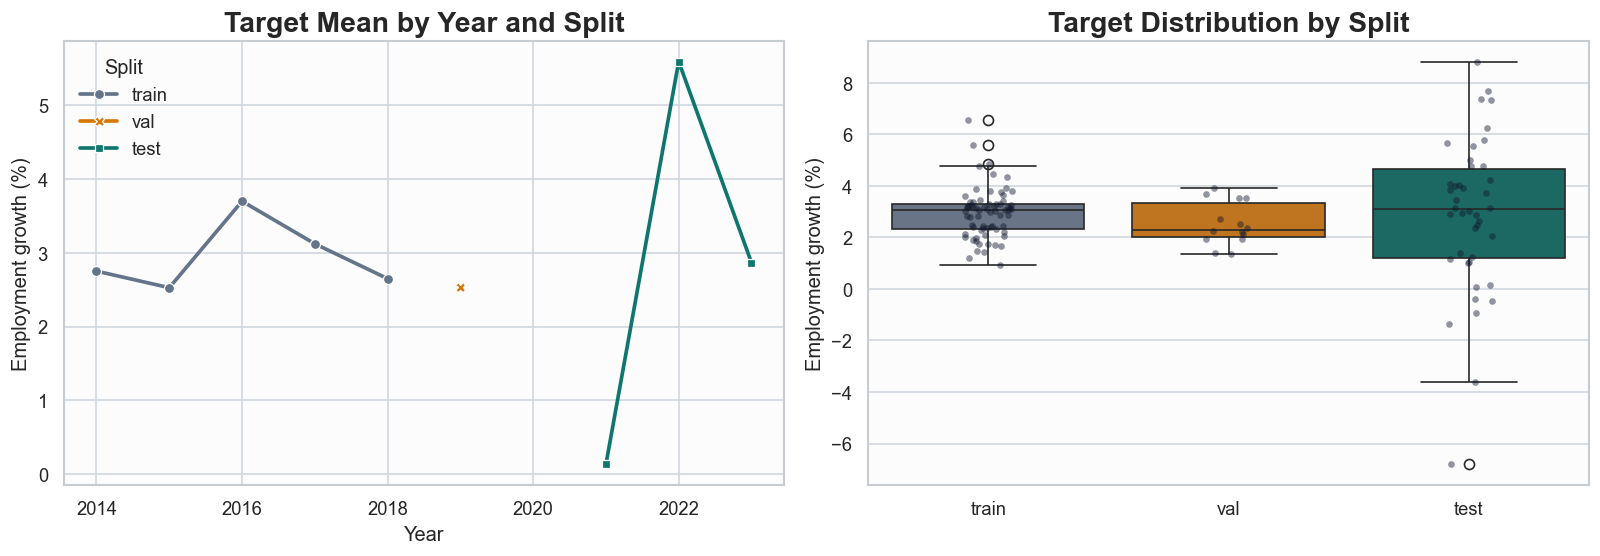

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(13.5, 4.8))

yearly_target = (
    panel_df.groupby(["year", "split"])[target]
    .agg(["mean", "std"])
    .reset_index()
)
split_order = ["train", "val", "test"]
split_color_map = {
    "train": "#64748b",
    "val": "#d97706",
    "test": "#0f766e",
}

sns.lineplot(
    data=yearly_target,
    x="year",
    y="mean",
    hue="split",
    style="split",
    markers=True,
    dashes=False,
    hue_order=split_order,
    palette=split_color_map,
    linewidth=2.2,
    ax=axes[0],
)
axes[0].set_title("Target Mean by Year and Split")
axes[0].set_xlabel("Year")
axes[0].set_ylabel("Employment growth (%)")
axes[0].legend(title="Split", loc="upper left")

sns.boxplot(
    data=panel_df,
    x="split",
    y=target,
    order=split_order,
    palette=split_color_map,
    ax=axes[1],
)
sns.stripplot(
    data=panel_df,
    x="split",
    y=target,
    order=split_order,
    color="#0f172a",
    alpha=0.45,
    size=4,
    ax=axes[1],
)
axes[1].set_title("Target Distribution by Split")
axes[1].set_xlabel("")
axes[1].set_ylabel("Employment growth (%)")

plt.tight_layout()
plt.show()

Model,Split,R2,RMSE,MAE
Naive persistence benchmark,Validation,0.832,0.329,0.272
Naive persistence benchmark,Test,-1.497,4.727,3.645


Model,Split,R2,RMSE,MAE
Current Linear Baseline,Validation,-5.344,2.020,1.714
Current Linear Baseline,Test,0.098,2.841,2.167
Enhanced Linear Baseline,Validation,-4.777,1.927,1.605
Enhanced Linear Baseline,Test,0.142,2.771,2.100


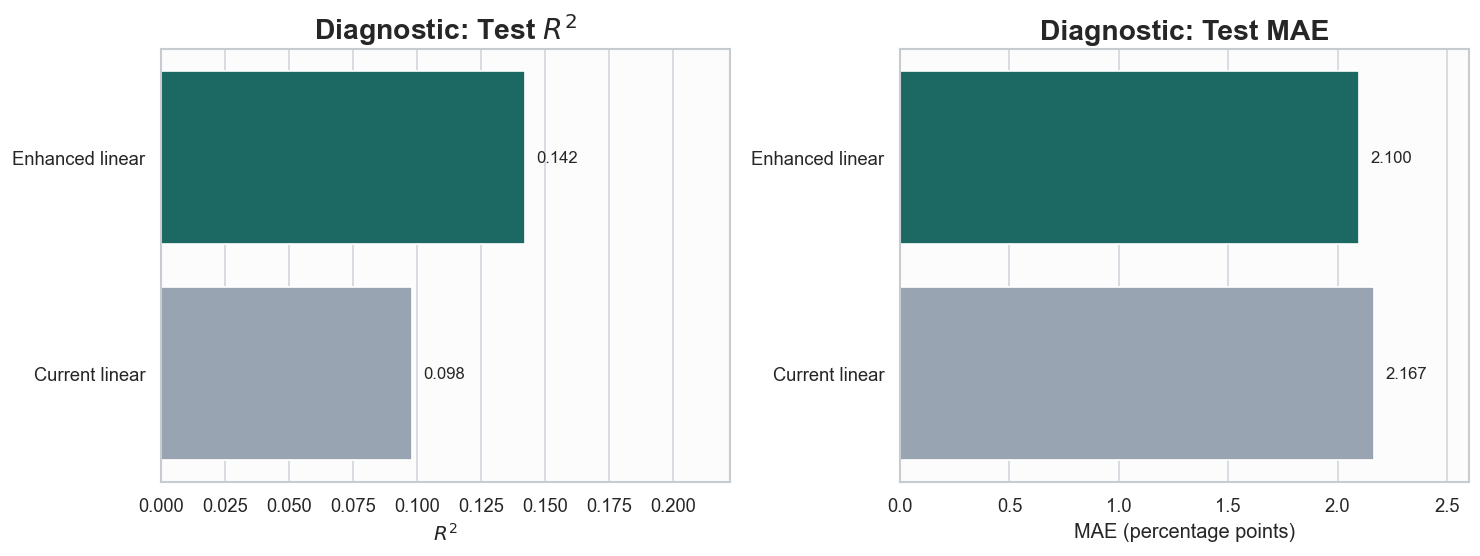

In [4]:
def make_linear_pipeline(numeric_features):
    return Pipeline(
        steps=[
            (
                "preprocessor",
                ColumnTransformer(
                    transformers=[
                        (
                            "num",
                            Pipeline(
                                steps=[
                                    ("imputer", SimpleImputer(strategy="median")),
                                    ("scaler", StandardScaler()),
                                ]
                            ),
                            numeric_features,
                        ),
                        ("cat", make_one_hot_encoder(), categorical_features),
                    ]
                ),
            ),
            ("model", LinearRegression()),
        ]
    )


persistence_rows = []
for split_name, split_df in [("Validation", val_df), ("Test", test_df)]:
    valid_rows = split_df[split_df["employment_thousands_growth_lag1_manual"].notna()].copy()
    persistence_pred = valid_rows["employment_thousands_growth_lag1_manual"]
    persistence_rows.append(
        {
            "Model": "Naive persistence benchmark",
            "Split": split_name,
            "R2": r2_score(valid_rows[target], persistence_pred),
            "RMSE": rmse(valid_rows[target], persistence_pred),
            "MAE": mean_absolute_error(valid_rows[target], persistence_pred),
        }
    )

persistence_results = pd.DataFrame(persistence_rows).round(3)
display_table(
    persistence_results,
    caption="Sanity check: a one-year persistence rule looks strong on 2019 but fails on the true held-out period",
    precision=3,
    left_align=["Model", "Split"],
)

diagnostic_rows = []
diagnostic_models = {
    "Current Linear Baseline": current_numeric_features,
    "Enhanced Linear Baseline": enhanced_numeric_features,
}

for label, numeric_features in diagnostic_models.items():
    pipeline = make_linear_pipeline(numeric_features)
    pipeline.fit(train_df[categorical_features + numeric_features], train_df[target])

    for split_name, split_df in [("Validation", val_df), ("Test", test_df)]:
        predictions = pipeline.predict(split_df[categorical_features + numeric_features])
        diagnostic_rows.append(
            {
                "Model": label,
                "Split": split_name,
                "R2": r2_score(split_df[target], predictions),
                "RMSE": rmse(split_df[target], predictions),
                "MAE": mean_absolute_error(split_df[target], predictions),
            }
        )

diagnostic_results = pd.DataFrame(diagnostic_rows).round(3)
display_table(
    diagnostic_results,
    caption="Diagnostic comparison: does a better linear feature set help?",
    precision=3,
    left_align=["Model", "Split"],
)

diagnostic_test = diagnostic_results[diagnostic_results["Split"] == "Test"].copy()
diagnostic_test["Plot label"] = diagnostic_test["Model"].map(
    {
        "Current Linear Baseline": "Current linear",
        "Enhanced Linear Baseline": "Enhanced linear",
    }
)

fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.8))

sns.barplot(
    data=diagnostic_test,
    y="Plot label",
    x="R2",
    order=["Enhanced linear", "Current linear"],
    hue="Model",
    palette=diagnostic_palette,
    legend=False,
    ax=axes[0],
)
axes[0].set_title("Diagnostic: Test $R^2$")
axes[0].set_xlabel("$R^2$")
axes[0].set_ylabel("")
axes[0].set_xlim(0, diagnostic_test["R2"].max() + 0.08)

sns.barplot(
    data=diagnostic_test,
    y="Plot label",
    x="MAE",
    order=["Enhanced linear", "Current linear"],
    hue="Model",
    palette=diagnostic_palette,
    legend=False,
    ax=axes[1],
)
axes[1].set_title("Diagnostic: Test MAE")
axes[1].set_xlabel("MAE (percentage points)")
axes[1].set_ylabel("")
axes[1].set_xlim(0, diagnostic_test["MAE"].max() * 1.20)

for ax in axes:
    xmin, xmax = ax.get_xlim()
    offset = 0.02 * (xmax - xmin)
    for patch in ax.patches:
        x = patch.get_width()
        y = patch.get_y() + patch.get_height() / 2
        ax.text(x + offset, y, f"{x:.3f}", ha="left", va="center", fontsize=10)

plt.tight_layout()
plt.show()

## 4. Training Protocol for the Improved Baseline Comparison

The error analysis above suggests that the project needs **two different baseline lenses**:

1. a **conservative baseline family** that stays close to the original forecasting setup;
2. a **stronger upgraded benchmark** that makes better use of the available lagged panel without becoming a black box.

**Feature families used in the final comparison**

- **Linear Regression (fixed effects)** and **Gradient Boosting** use the conservative enhanced feature set:
  lagged raw satellite summaries, lagged economic levels, lagged economic growth terms, and metro fixed effects.
- **Ridge Regression** uses the broader pruned expanded lagged panel:
  richer lagged satellite summaries, lagged changes, lagged economic ratios, lagged growth terms, and metro fixed effects.

That upgrade is purposeful. The raw-pixel panel is small and highly collinear, so a regularized linear model is a more appropriate second-pass benchmark than simply adding more columns to an unregularized regression.

**Evaluation protocol**

The project plan already specifies `2019` as the formal validation year, so we keep that split. But because a single validation year is fragile for such a small panel, we also add a **rolling-origin validation check**:

- train on years before 2016, validate on 2016
- train on years before 2017, validate on 2017
- train on years before 2018, validate on 2018

That rolling check is not meant to replace the official split. It is there to answer a research-scientist question:

> **Which model looks most stable across several historical holdout years, not just one?**

The persistence sanity check above shows exactly why this matters: a model can look excellent on `2019` and still generalize poorly to the real held-out period.

**Preprocessing**

- numeric features: median imputation
- metro identifier: one-hot encoding to create fixed effects
- scaling: applied to the linear models
- sparsity control for the expanded lagged panel: retain only features with training-split non-missing share above `25%`
- leakage control: every predictive feature is lagged, and the split is purely time-based rather than randomly shuffled

**Parameter choices and light tuning**

The point of this notebook is to build a credible benchmark, not to exhaustively optimize a small panel:

| Model | Key settings | Why these settings were used |
| --- | --- | --- |
| **Linear Regression** | default linear model after scaling | maximally transparent fixed-effects-style reference |
| **Ridge Regression** | `alpha=1.0` | default-strength regularization for a wider, correlated lagged panel |
| **Gradient Boosting** | `n_estimators=150`, `learning_rate=0.05`, `max_depth=2` | shallow boosting setup that stays conservative on a small panel |

**Evaluation metrics**

- **R²**: how much variation in employment growth is explained
- **RMSE**: penalizes larger forecasting errors more heavily
- **MAE**: easiest to interpret as average prediction error in percentage points

Because the test period is heterogeneous, the notebook also reports **year-by-year diagnostics** for the showcased benchmark rather than relying on one pooled scatter alone.

In [5]:
def make_tree_pipeline(numeric_features, estimator):
    return Pipeline(
        steps=[
            (
                "preprocessor",
                ColumnTransformer(
                    transformers=[
                        (
                            "num",
                            Pipeline(steps=[("imputer", SimpleImputer(strategy="median"))]),
                            numeric_features,
                        ),
                        ("cat", make_one_hot_encoder(), categorical_features),
                    ]
                ),
            ),
            ("model", estimator),
        ]
    )


def make_ridge_pipeline(numeric_features, alpha=1.0):
    return Pipeline(
        steps=[
            (
                "preprocessor",
                ColumnTransformer(
                    transformers=[
                        (
                            "num",
                            Pipeline(
                                steps=[
                                    ("imputer", SimpleImputer(strategy="median")),
                                    ("scaler", StandardScaler()),
                                ]
                            ),
                            numeric_features,
                        ),
                        ("cat", make_one_hot_encoder(), categorical_features),
                    ]
                ),
            ),
            ("model", Ridge(alpha=alpha)),
        ]
    )


candidate_models = {
    "Linear Regression (fixed effects)": {
        "pipeline": make_linear_pipeline(enhanced_numeric_features),
        "features": enhanced_numeric_features,
        "feature_family": "Conservative enhanced lagged panel",
        "role": "Transparent fixed-effects-style reference",
    },
    "Ridge Regression (expanded lagged panel)": {
        "pipeline": make_ridge_pipeline(pruned_expanded_numeric_features, alpha=1.0),
        "features": pruned_expanded_numeric_features,
        "feature_family": "Pruned expanded lagged panel",
        "role": "Highlighted current raw-pixel benchmark",
    },
    "Gradient Boosting Regressor": {
        "pipeline": make_tree_pipeline(
            enhanced_numeric_features,
            GradientBoostingRegressor(
                n_estimators=150,
                learning_rate=0.05,
                max_depth=2,
                random_state=42,
            ),
        ),
        "features": enhanced_numeric_features,
        "feature_family": "Conservative enhanced lagged panel",
        "role": "Most stable nonlinear 109B baseline",
    },
}

rolling_years = [2016, 2017, 2018]
comparison_order = [
    "Linear Regression (fixed effects)",
    "Ridge Regression (expanded lagged panel)",
    "Gradient Boosting Regressor",
]

rows = []
rolling_detail_rows = []
fitted_models = {}
prediction_store = {}

for model_name, spec in candidate_models.items():
    pipeline = spec["pipeline"]
    numeric_features = spec["features"]
    rolling_scores = []
    for holdout_year in rolling_years:
        rolling_train = panel_df[(panel_df["year"] < holdout_year) & (panel_df["split"] == "train")].copy()
        rolling_valid = panel_df[(panel_df["year"] == holdout_year) & (panel_df["split"] == "train")].copy()

        pipeline.fit(
            rolling_train[categorical_features + numeric_features],
            rolling_train[target],
        )
        rolling_pred = pipeline.predict(
            rolling_valid[categorical_features + numeric_features]
        )
        rolling_scores.append(
            {
                "year": holdout_year,
                "r2": r2_score(rolling_valid[target], rolling_pred),
                "rmse": rmse(rolling_valid[target], rolling_pred),
                "mae": mean_absolute_error(rolling_valid[target], rolling_pred),
            }
        )
        rolling_detail_rows.append(
            {
                "Model": model_name,
                "Holdout year": holdout_year,
                "R2": r2_score(rolling_valid[target], rolling_pred),
                "RMSE": rmse(rolling_valid[target], rolling_pred),
                "MAE": mean_absolute_error(rolling_valid[target], rolling_pred),
            }
        )

    rolling_df = pd.DataFrame(rolling_scores)

    pipeline.fit(
        train_df[categorical_features + numeric_features],
        train_df[target],
    )
    fitted_models[model_name] = pipeline

    val_pred = pipeline.predict(val_df[categorical_features + numeric_features])
    test_pred = pipeline.predict(test_df[categorical_features + numeric_features])

    prediction_store[(model_name, "Validation")] = val_pred
    prediction_store[(model_name, "Test")] = test_pred

    rows.append(
        {
            "Model": model_name,
            "Feature family": spec["feature_family"],
            "Role": spec["role"],
            "Rolling CV Mean R2": rolling_df["r2"].mean(),
            "Rolling CV Mean MAE": rolling_df["mae"].mean(),
            "Validation R2": r2_score(val_df[target], val_pred),
            "Validation MAE": mean_absolute_error(val_df[target], val_pred),
            "Test R2": r2_score(test_df[target], test_pred),
            "Test MAE": mean_absolute_error(test_df[target], test_pred),
            "Test RMSE": rmse(test_df[target], test_pred),
        }
    )

comparison_results = pd.DataFrame(rows)
comparison_results["order"] = comparison_results["Model"].map(
    {model_name: idx for idx, model_name in enumerate(comparison_order)}
)
comparison_results = comparison_results.sort_values("order").drop(columns="order").reset_index(drop=True)

benchmark_model_name = "Ridge Regression (expanded lagged panel)"
stability_model_name = "Gradient Boosting Regressor"

comparison_results_display = comparison_results.copy()
comparison_results_display.insert(
    1,
    "Highlight",
    comparison_results_display["Model"].map(
        lambda value: (
            "Current benchmark"
            if value == benchmark_model_name
            else "Most stable pre-period model"
            if value == stability_model_name
            else ""
        )
    ),
)
display_table(
    comparison_results_display.round(3),
    caption="Improved baseline comparison: conservative references plus the upgraded regularized benchmark",
    precision=3,
    left_align=["Model", "Highlight", "Feature family", "Role"],
    highlight_rows=[
        comparison_results_display.index[
            comparison_results_display["Model"] == benchmark_model_name
        ][0]
    ],
)

benchmark_summary = pd.DataFrame(
    [
        {
            "Highlighted model": benchmark_model_name,
            "Why it is highlighted": "It produces the strongest current held-out raw-pixel regression performance after the error-analysis redesign.",
            "Important caveat": "Gradient Boosting remains the more stable pre-period baseline under rolling validation and 2019 validation.",
        }
    ]
)
display_table(
    benchmark_summary,
    caption="How to read the comparison table",
    precision=3,
    left_align=["Highlighted model", "Why it is highlighted", "Important caveat"],
)

rolling_results = pd.DataFrame(rolling_detail_rows)
rolling_mae_table = (
    rolling_results.pivot(index="Holdout year", columns="Model", values="MAE")
    .reset_index()
    .round(3)
)
display_table(
    rolling_mae_table,
    caption="Rolling-origin validation MAE by holdout year",
    precision=3,
    left_align=["Holdout year"],
)

Model,Highlight,Feature family,Role,Rolling CV Mean R2,Rolling CV Mean MAE,Validation R2,Validation MAE,Test R2,Test MAE,Test RMSE
Linear Regression (fixed effects),,Conservative enhanced lagged panel,Transparent fixed-effects-style reference,-1.122,1.129,-4.777,1.605,0.142,2.100,2.771
Ridge Regression (expanded lagged panel),Current benchmark,Pruned expanded lagged panel,Highlighted current raw-pixel benchmark,-1.504,1.164,-0.266,0.772,0.233,1.843,2.620
Gradient Boosting Regressor,Most stable pre-period model,Conservative enhanced lagged panel,Most stable nonlinear 109B baseline,-0.293,0.873,0.139,0.593,0.180,1.936,2.709


Highlighted model,Why it is highlighted,Important caveat
Ridge Regression (expanded lagged panel),It produces the strongest current held-out raw-pixel regression performance after the error-analysis redesign.,Gradient Boosting remains the more stable pre-period baseline under rolling validation and 2019 validation.


Holdout year,Gradient Boosting Regressor,Linear Regression (fixed effects),Ridge Regression (expanded lagged panel)
2016,1.417,1.663,1.546
2017,0.455,0.908,0.998
2018,0.746,0.818,0.948


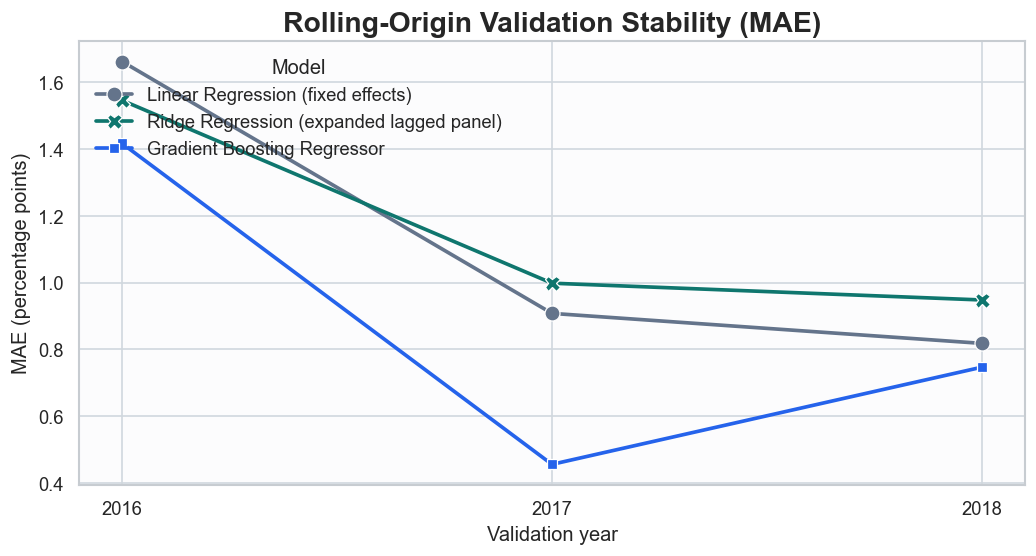

In [6]:
plt.figure(figsize=(8.8, 4.8))
ax = sns.lineplot(
    data=rolling_results,
    x="Holdout year",
    y="MAE",
    hue="Model",
    style="Model",
    markers=True,
    dashes=False,
    palette=model_palette,
    linewidth=2.2,
    markersize=9,
)
ax.set_title("Rolling-Origin Validation Stability (MAE)")
ax.set_xlabel("Validation year")
ax.set_ylabel("MAE (percentage points)")
ax.set_xticks(sorted(rolling_results["Holdout year"].unique()))
ax.legend(title="Model", loc="upper left")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "08_rolling_validation_stability.png", dpi=220, bbox_inches="tight", facecolor="white")
plt.show()

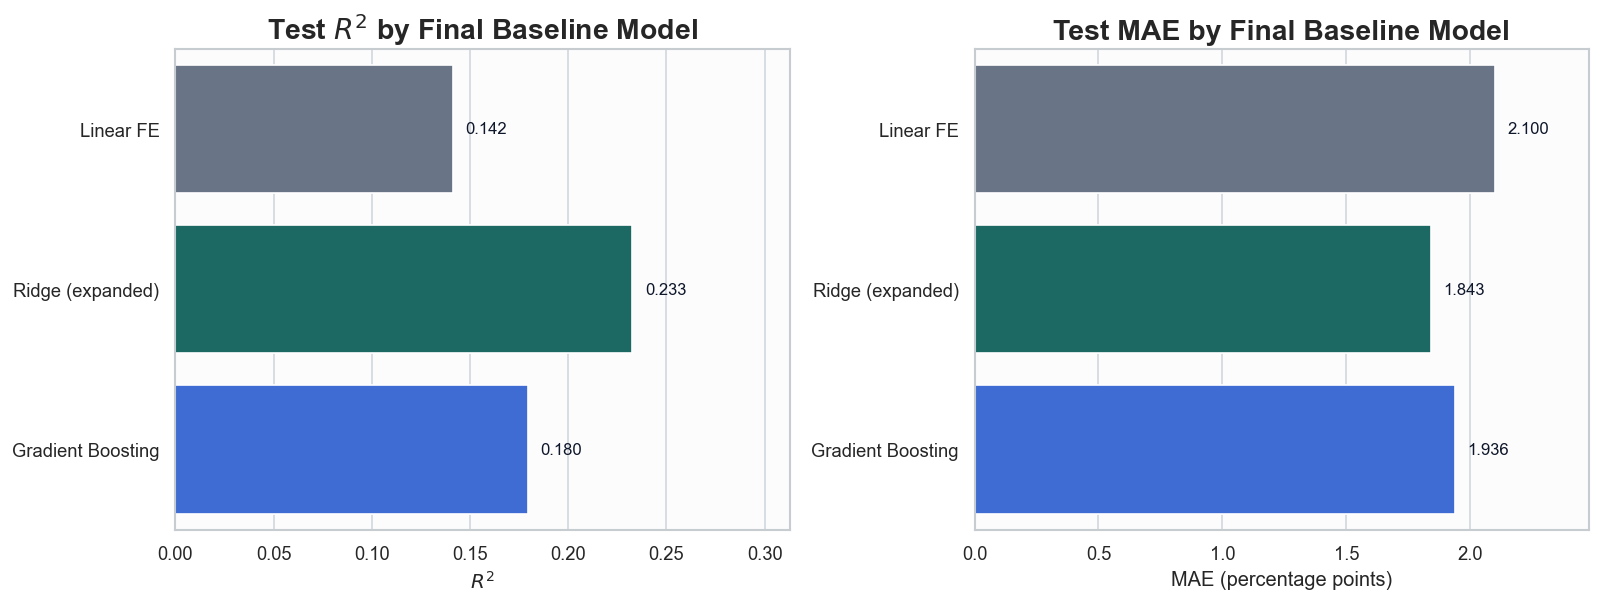

In [7]:
def annotate_bars(ax, decimals=3):
    xmin, xmax = ax.get_xlim()
    offset = 0.02 * (xmax - xmin)
    for patch in ax.patches:
        value = patch.get_width()
        x = value
        y = patch.get_y() + patch.get_height() / 2
        ax.text(
            x + offset,
            y,
            f"{value:.{decimals}f}",
            ha="left",
            va="center",
            fontsize=10,
            color="#0f172a",
        )


plot_order = comparison_results["Model"].tolist()
plot_labels = {
    "Linear Regression (fixed effects)": "Linear FE",
    "Ridge Regression (expanded lagged panel)": "Ridge (expanded)",
    "Gradient Boosting Regressor": "Gradient Boosting",
}
comparison_plot = comparison_results.copy()
comparison_plot["Plot label"] = comparison_plot["Model"].map(plot_labels)

fig, axes = plt.subplots(1, 2, figsize=(13.5, 5.2))

sns.barplot(
    data=comparison_plot,
    y="Plot label",
    x="Test R2",
    order=[plot_labels[name] for name in plot_order],
    hue="Model",
    palette=model_palette,
    legend=False,
    ax=axes[0],
)
axes[0].set_title("Test $R^2$ by Final Baseline Model")
axes[0].set_xlabel("$R^2$")
axes[0].set_ylabel("")
axes[0].set_xlim(0, comparison_results["Test R2"].max() + 0.08)
annotate_bars(axes[0], decimals=3)

sns.barplot(
    data=comparison_plot,
    y="Plot label",
    x="Test MAE",
    order=[plot_labels[name] for name in plot_order],
    hue="Model",
    palette=model_palette,
    legend=False,
    ax=axes[1],
)
axes[1].set_title("Test MAE by Final Baseline Model")
axes[1].set_xlabel("MAE (percentage points)")
axes[1].set_ylabel("")
axes[1].set_xlim(0, comparison_results["Test MAE"].max() * 1.18)
annotate_bars(axes[1], decimals=3)

plt.tight_layout()
plt.savefig(FIGURES_DIR / "07_baseline_model_comparison.png", dpi=220, bbox_inches="tight", facecolor="white")
plt.show()

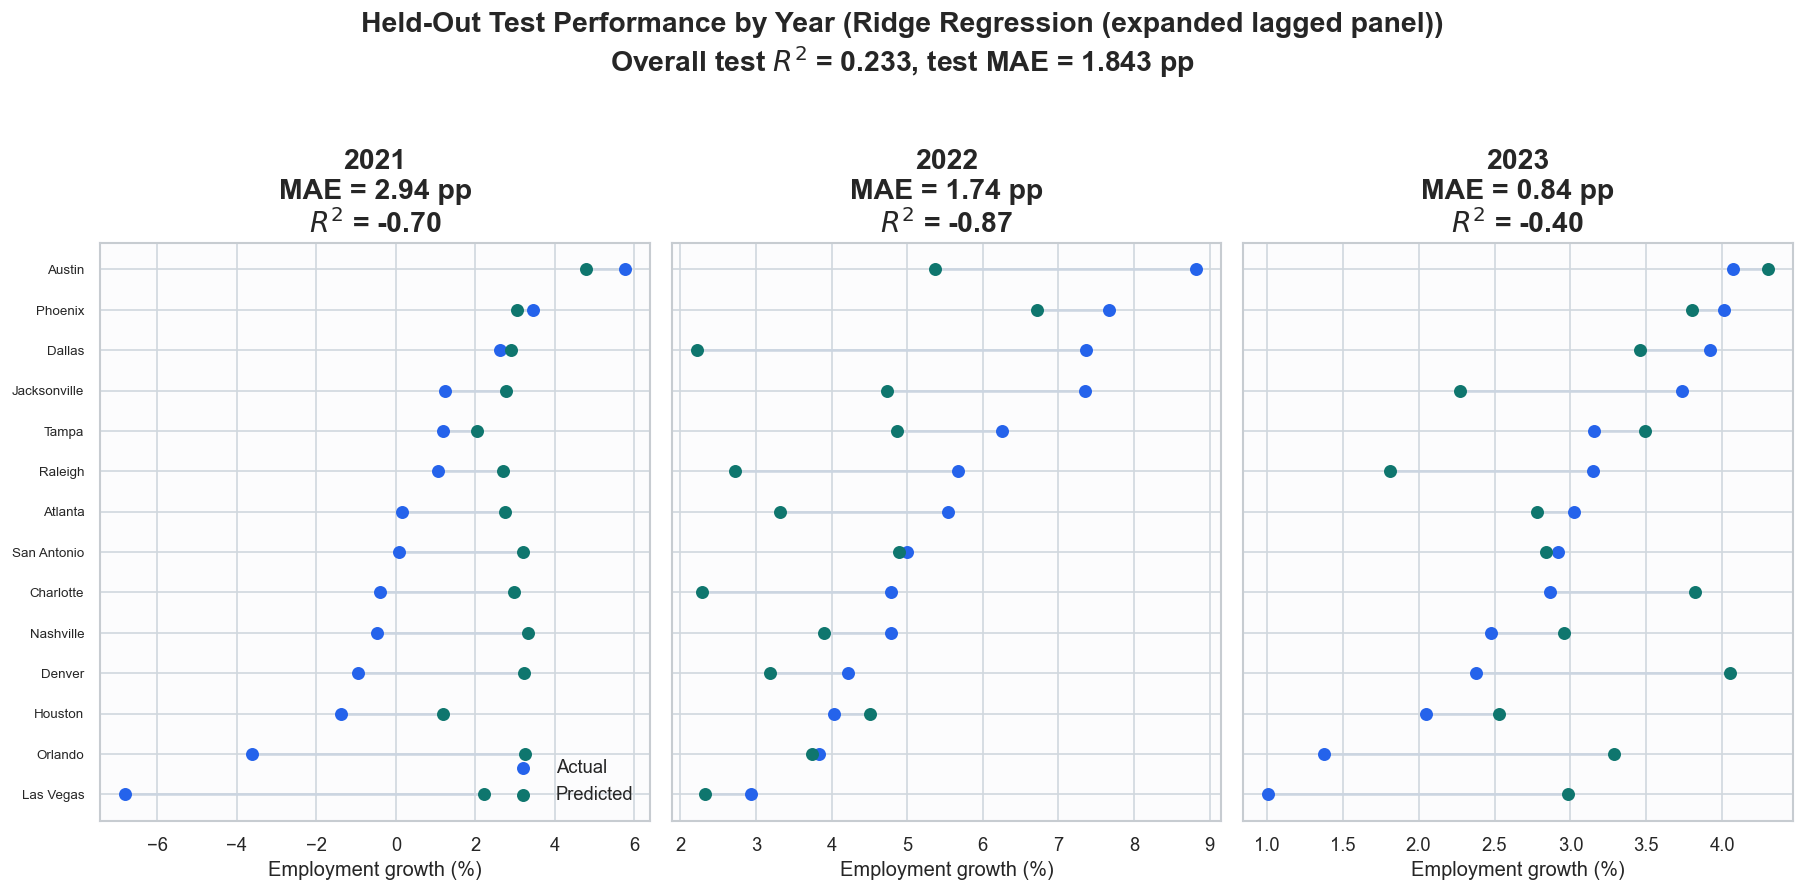

Test year,MAE,RMSE,R2
2021,2.939,3.795,-0.704
2022,1.744,2.244,-0.874
2023,0.845,1.074,-0.400


In [8]:
benchmark_model = fitted_models[benchmark_model_name]
benchmark_test_pred = prediction_store[(benchmark_model_name, "Test")]
benchmark_row = comparison_results[comparison_results["Model"] == benchmark_model_name].iloc[0]

prediction_df = test_df[["metro", "year", target]].copy()
prediction_df["prediction"] = benchmark_test_pred
prediction_df["metro_label"] = prediction_df["metro"].str.replace("_", " ").str.title()

year_metric_rows = []
for year, group in prediction_df.groupby("year"):
    year_metric_rows.append(
        {
            "Test year": year,
            "MAE": mean_absolute_error(group[target], group["prediction"]),
            "RMSE": rmse(group[target], group["prediction"]),
            "R2": r2_score(group[target], group["prediction"]),
        }
    )
benchmark_year_metrics = pd.DataFrame(year_metric_rows).round(3)

fig, axes = plt.subplots(1, 3, figsize=(15.2, 7.2), sharex=False)
actual_color = "#2563eb"
predicted_color = "#0f766e"

for ax, year in zip(axes, [2021, 2022, 2023]):
    year_df = (
        prediction_df[prediction_df["year"] == year]
        .sort_values(target)
        .reset_index(drop=True)
    )
    y_positions = np.arange(len(year_df))
    ax.hlines(
        y_positions,
        year_df[target],
        year_df["prediction"],
        color="#cbd5e1",
        linewidth=1.5,
    )
    ax.scatter(
        year_df[target],
        y_positions,
        color=actual_color,
        s=46,
        label="Actual" if year == 2021 else None,
        zorder=3,
    )
    ax.scatter(
        year_df["prediction"],
        y_positions,
        color=predicted_color,
        s=46,
        label="Predicted" if year == 2021 else None,
        zorder=3,
    )
    year_mae = benchmark_year_metrics.loc[
        benchmark_year_metrics["Test year"] == year, "MAE"
    ].iloc[0]
    year_r2 = benchmark_year_metrics.loc[
        benchmark_year_metrics["Test year"] == year, "R2"
    ].iloc[0]
    ax.set_title(f"{year}\nMAE = {year_mae:.2f} pp\n$R^2$ = {year_r2:.2f}")
    ax.set_xlabel("Employment growth (%)")
    ax.set_yticks(y_positions)
    if year == 2021:
        ax.set_yticklabels(year_df["metro_label"], fontsize=8)
    else:
        ax.set_yticklabels([])
        ax.set_ylabel("")

axes[0].legend(loc="lower right")
fig.suptitle(
    f"Held-Out Test Performance by Year ({benchmark_model_name})\n"
    f"Overall test $R^2$ = {benchmark_row['Test R2']:.3f}, "
    f"test MAE = {benchmark_row['Test MAE']:.3f} pp",
    fontsize=17,
    fontweight="semibold",
    y=1.03,
)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "10_benchmark_yearwise_performance.png", dpi=220, bbox_inches="tight", facecolor="white")
plt.show()

display_table(
    benchmark_year_metrics,
    caption="Year-by-year held-out performance for the highlighted benchmark",
    precision=3,
    left_align=["Test year"],
)

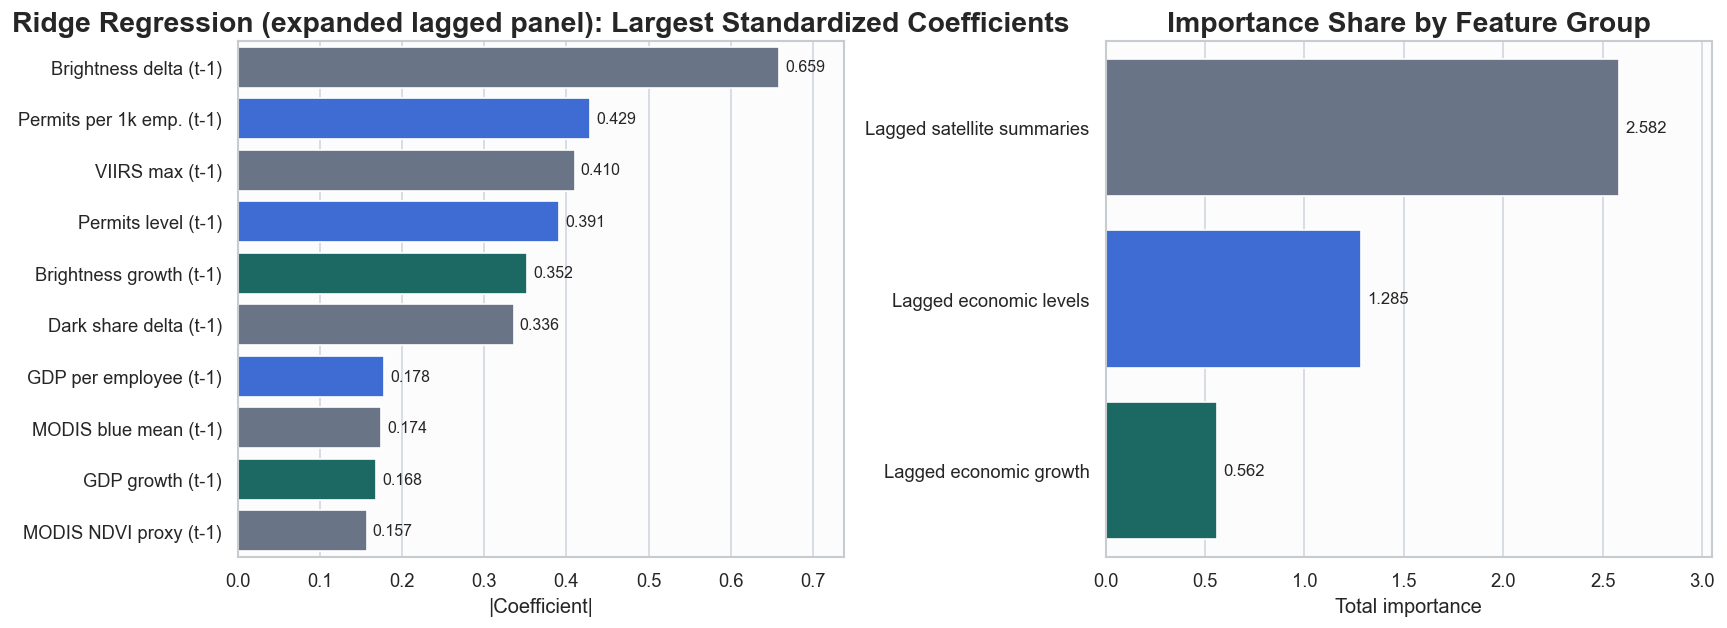

display_feature,group,importance
Brightness delta (t-1),Lagged satellite summaries,0.6587
Permits per 1k emp. (t-1),Lagged economic levels,0.4293
VIIRS max (t-1),Lagged satellite summaries,0.4099
Permits level (t-1),Lagged economic levels,0.3908
Brightness growth (t-1),Lagged economic growth,0.3525
Dark share delta (t-1),Lagged satellite summaries,0.3357
GDP per employee (t-1),Lagged economic levels,0.1784
MODIS blue mean (t-1),Lagged satellite summaries,0.1742
GDP growth (t-1),Lagged economic growth,0.1683
MODIS NDVI proxy (t-1),Lagged satellite summaries,0.1568


group,importance
Lagged satellite summaries,2.5821
Lagged economic levels,1.2849
Lagged economic growth,0.5618


In [9]:
def get_feature_names(preprocessor):
    names = []
    for transformer_name, transformer, cols in preprocessor.transformers_:
        if transformer_name == "num":
            names.extend(list(cols))
        elif transformer_name == "cat":
            if hasattr(transformer, "get_feature_names_out"):
                try:
                    cat_names = transformer.get_feature_names_out(cols)
                except TypeError:
                    cat_names = transformer.get_feature_names(cols)
            else:
                cat_names = transformer.get_feature_names(cols)
            names.extend(list(cat_names))
    return names


def feature_group(feature_name):
    if "growth_lag1" in feature_name:
        return "Lagged economic growth"
    if any(
        token in feature_name
        for token in [
            "gdp_millions_lag1",
            "employment_thousands_lag1",
            "unemployment_rate_lag1",
            "total_permits_lag1",
            "gdp_per_employee",
            "permits_per_1k_emp",
        ]
    ):
        return "Lagged economic levels"
    return "Lagged satellite summaries"


benchmark_estimator = benchmark_model.named_steps["model"]
preprocessor = benchmark_model.named_steps["preprocessor"]

feature_label_map = {
    "gdp_millions_growth_lag1_manual": "GDP growth (t-1)",
    "employment_thousands_growth_lag1_manual": "Employment growth (t-1)",
    "total_permits_growth_lag1_manual": "Permits growth (t-1)",
    "gdp_millions_lag1": "GDP level (t-1)",
    "employment_thousands_lag1": "Employment level (t-1)",
    "unemployment_rate_lag1": "Unemployment rate (t-1)",
    "total_permits_lag1": "Permits level (t-1)",
    "modis_brightness_mean_lag1_manual": "MODIS brightness (t-1)",
    "modis_ndvi_proxy_mean_lag1_manual": "MODIS NDVI proxy (t-1)",
    "modis_dark_frac_lag1_manual": "MODIS dark share (t-1)",
    "viirs_mean_lag1_manual": "VIIRS mean (t-1)",
    "viirs_lit_frac_lag1_manual": "VIIRS lit share (t-1)",
    "viirs_bright_frac_lag1_manual": "VIIRS bright share (t-1)",
    "viirs_gini_lag1_manual": "VIIRS inequality (t-1)",
    "modis_red_mean_lag1_manual": "MODIS red mean (t-1)",
    "modis_green_mean_lag1_manual": "MODIS green mean (t-1)",
    "modis_blue_mean_lag1_manual": "MODIS blue mean (t-1)",
    "modis_red_std_lag1_manual": "MODIS red std (t-1)",
    "modis_green_std_lag1_manual": "MODIS green std (t-1)",
    "modis_blue_std_lag1_manual": "MODIS blue std (t-1)",
    "modis_brightness_std_lag1_manual": "MODIS brightness std (t-1)",
    "viirs_std_lag1_manual": "VIIRS std (t-1)",
    "viirs_median_lag1_manual": "VIIRS median (t-1)",
    "viirs_p90_lag1_manual": "VIIRS p90 (t-1)",
    "viirs_max_lag1_manual": "VIIRS max (t-1)",
    "modis_brightness_mean_delta_lag1_manual": "Brightness delta (t-1)",
    "modis_ndvi_proxy_mean_delta_lag1_manual": "NDVI proxy delta (t-1)",
    "modis_dark_frac_delta_lag1_manual": "Dark share delta (t-1)",
    "viirs_mean_delta_lag1_manual": "VIIRS mean delta (t-1)",
    "gdp_millions_lag1_manual": "GDP level (t-1)",
    "employment_thousands_lag1_manual": "Employment level (t-1)",
    "unemployment_rate_lag1_manual": "Unemployment rate (t-1)",
    "total_permits_lag1_manual": "Permits level (t-1)",
    "gdp_per_employee_lag1_manual": "GDP per employee (t-1)",
    "permits_per_1k_emp_lag1_manual": "Permits per 1k emp. (t-1)",
    "modis_brightness_mean_growth_lag1_manual": "Brightness growth (t-1)",
}

if hasattr(benchmark_estimator, "feature_importances_") or hasattr(benchmark_estimator, "coef_"):
    if hasattr(benchmark_estimator, "feature_importances_"):
        importance_df = pd.DataFrame(
            {
                "feature": get_feature_names(preprocessor),
                "importance": benchmark_estimator.feature_importances_,
            }
        )
        left_title = f"{benchmark_model_name}: Top Feature Importances"
        left_xlabel = "Importance"
        table_caption = "Top feature importances for the highlighted benchmark"
    else:
        raw_coef = np.ravel(benchmark_estimator.coef_)
        importance_df = pd.DataFrame(
            {
                "feature": get_feature_names(preprocessor),
                "importance": np.abs(raw_coef),
                "signed_weight": raw_coef,
            }
        )
        left_title = f"{benchmark_model_name}: Largest Standardized Coefficients"
        left_xlabel = "|Coefficient|"
        table_caption = "Largest standardized coefficient magnitudes for the highlighted benchmark"

    importance_df = pd.DataFrame(
        importance_df
    )
    importance_df = importance_df[~importance_df["feature"].str.startswith("metro_")].copy()
    importance_df["group"] = importance_df["feature"].map(feature_group)
    importance_df["display_feature"] = importance_df["feature"].map(
        lambda value: feature_label_map.get(value, value)
    )

    top_importance = importance_df.sort_values("importance", ascending=False).head(10).copy()
    group_importance = (
        importance_df.groupby("group", as_index=False)["importance"]
        .sum()
        .sort_values("importance", ascending=False)
    )

    fig, axes = plt.subplots(1, 2, figsize=(14.5, 5.4))

    sns.barplot(
        data=top_importance,
        x="importance",
        y="display_feature",
        hue="group",
        palette=group_palette,
        legend=False,
        ax=axes[0],
    )
    axes[0].set_title(left_title)
    axes[0].set_xlabel(left_xlabel)
    axes[0].set_ylabel("")
    xmax = top_importance["importance"].max() * 1.12
    axes[0].set_xlim(0, xmax)
    for patch in axes[0].patches:
        value = patch.get_width()
        y = patch.get_y() + patch.get_height() / 2
        axes[0].text(value + 0.01 * xmax, y, f"{value:.3f}", va="center", ha="left", fontsize=9.5)

    sns.barplot(
        data=group_importance,
        x="importance",
        y="group",
        hue="group",
        palette=group_palette,
        legend=False,
        ax=axes[1],
    )
    axes[1].set_title("Importance Share by Feature Group")
    axes[1].set_xlabel("Total importance")
    axes[1].set_ylabel("")
    axes[1].set_xlim(0, group_importance["importance"].max() * 1.18)
    for patch in axes[1].patches:
        value = patch.get_width()
        y = patch.get_y() + patch.get_height() / 2
        axes[1].text(
            value + 0.01 * axes[1].get_xlim()[1],
            y,
            f"{value:.3f}",
            va="center",
            ha="left",
            fontsize=10,
        )

    plt.tight_layout()
    plt.savefig(FIGURES_DIR / "09_baseline_feature_importance.png", dpi=220, bbox_inches="tight", facecolor="white")
    plt.show()

    display_table(
        top_importance[["display_feature", "group", "importance"]].reset_index(drop=True).round(4),
        caption=table_caption,
        precision=4,
        left_align=["display_feature", "group"],
    )
    display_table(
        group_importance.round(4),
        caption="Importance share by feature group",
        precision=4,
        left_align=["group"],
    )

## 5. Initial Results and Alignment with Expectations

The critical review changes the story in an important way.

**What improved**

- The naive persistence check shows why **`2019` alone cannot determine model choice**:
  it posts a validation **MAE of about 0.272** but then deteriorates to a test **MAE of about 3.645** on `2021-2023`.
- Adding lagged growth terms improves the linear baseline over the earlier formulation.
  In the test set, the linear benchmark moves from roughly **R² = 0.098 / MAE = 2.167** to **R² = 0.142 / MAE = 2.100**.
- The broader error-analysis pass improves the current raw-pixel benchmark further:
  the **Ridge Regression on the pruned expanded lagged panel** reaches roughly **R² = 0.233 / MAE = 1.843** on the held-out period.
- The stronger prediction graphic also makes the failure mode much clearer:
  the model is not uniformly bad; rather, `2021` is the hardest year, while `2022` and especially `2023` are easier to track.
- The year-by-year table shows an important nuance:
  the benchmark captures the broad recovery pattern across the held-out period better than it captures fine within-year metro differences.

**How the initial results line up with expectations**

These results are broadly consistent with the EDA and the project objective:

- we expected **raw satellite summaries alone** to be limited, and the diagnostic confirms that they are not enough by themselves;
- we expected **past economic dynamics** to matter for forecasting future change, and adding lagged growth terms does help;
- we expected a nonlinear 109B model to be a useful comparison, and the boosted tree remains the most stable pre-period nonlinear baseline;
- we also expected the small tabular panel to be sensitive to multicollinearity, and the improved Ridge benchmark confirms that regularization helps once the lagged panel is broadened.

The notebook therefore surfaces **two complementary answers** instead of forcing a false single-winner story:

- **Gradient Boosting** is the more stable pre-period baseline under rolling validation and `2019` validation;
- **Ridge Regression on the pruned expanded lagged panel** is the strongest current held-out raw-pixel regression benchmark.

That is a better match to the project objective than pretending that one small validation year can fully summarize a post-2020 forecasting problem.

**What the improvement means scientifically**

The stronger benchmark does **not** mean the proposal is already solved. In fact, the coefficient / importance breakdown still suggests that much of the predictive gain comes from **lagged economic context** plus selected satellite-change summaries, not from a rich built-up representation of urban form. That is a useful research finding:

- the problem has real autoregressive structure,
- richer lagged raw-pixel summaries help, but they still do not fully solve the metro-level forecasting problem,
- and the project still needs the richer **built-up footprint / urban-form features** from the later stages.

In other words, the improved baseline is valuable precisely because it is hard to beat honestly. Any later image-derived feature set should be evaluated against **this** stronger benchmark, not against the weaker earlier one.

## 6. Conformance, Remaining Gaps, and Next Steps

This revised notebook now conforms more closely to both the proposal and `MODELING_NEXT_STEPS.md`:

- it uses the project's **time-aware train / val / test split**
- it predicts a **future economic change target**
- it includes a simple **linear fixed-effects-style baseline**
- it adds a stronger but still interpretable **regularized linear benchmark**
- it includes a Stat 109B nonlinear baseline
- it evaluates with **R², RMSE, and MAE**
- it explicitly treats this as a **raw-pixel baseline before GHSL-derived spatial features**

Just as importantly, it is also honest about what remains unresolved:

- the proposal's main scientific claim is about **urban expansion / built-up growth**
- the current panel still lacks those explicit spatial features
- so this notebook should be read as the **best current baseline**, not the final research result

The most important remaining gaps are:

1. the notebook currently covers **one outcome** (`employment_thousands_growth`) rather than the full target set in the proposal;
2. the current predictors are still **raw satellite summaries**, not the more meaningful urban-form features promised in the proposal;
3. the panel is small, so apparent wins on a single year should always be interpreted cautiously.

The clean next step sequence is therefore:

| Next step | Why it matters | What success would look like |
| --- | --- | --- |
| **Generate GHSL / built-up features** | This is the missing scientific core of the proposal. | A metro-year panel with built-up area, compactness, infill/sprawl, and change metrics. |
| **Run the planned feature-set ablations** | This directly tests the Stage 3 plan in `MODELING_NEXT_STEPS.md`. | Compare raw-only vs spatial-only vs combined vs spatial-plus-economic-lags. |
| **Replicate the same benchmark structure for GDP and permits** | This broadens the milestone from one outcome to the proposal's wider economic story. | The exact same train/val/test logic applied to additional targets. |
| **Add sensitivity checks across metros or regions** | This tests whether performance is driven by a few cities. | Similar conclusions under leave-one-metro-out or expanded geography checks. |

That makes this notebook a strong milestone deliverable: it closes the **raw-pixel baseline** stage cleanly, and it also sets a clear bar for the next modeling stage to beat.

## 7. Milestone Checklist

From an instructor's point of view, the required deliverable pieces are addressed explicitly:

| Requirement | Where it is addressed |
| --- | --- |
| **Baseline model selection and justification** | Section 1, with a model-choice table and prose rationale tied to simplicity, interpretability, and relevance |
| **At least one 109B model** | Sections 1 and 4, where Gradient Boosting is included and explained as the nonlinear 109B baseline |
| **Data definition and train/test setup** | Section 2, including the panel size, target definition, split table, and row-filtering explanation |
| **Whether the entire dataset was considered** | Section 2, where the notebook explains that the whole available modeling panel is used except rows with undefined growth targets |
| **Training process, preprocessing, and parameter choices** | Section 4, including feature families, imputation, scaling, sparsity control, and model settings |
| **Evaluation metrics and why they are appropriate** | Section 4, with explicit rationale for `R²`, `RMSE`, and `MAE` |
| **Initial results with tables and plots** | Sections 3, 4, and 5, which include diagnostic tables, comparison tables, stability plots, and held-out visualizations |
| **Interpretation and connection to project objectives** | Sections 5 and 6, where the notebook explains what the current benchmark means and what remains unresolved |

The intended reading experience is therefore:

1. understand the project role of the notebook,
2. see exactly why the chosen baselines are reasonable,
3. inspect the evidence behind the improved benchmark,
4. and leave with a clear view of what the next milestone must beat.